<a href="https://colab.research.google.com/github/guthasushmasree/ML-LabPrograms/blob/main/ml(skill_5).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Please upload your placement CSV file...


Saving placement_predict_50k Dataset.csv to placement_predict_50k Dataset.csv

File uploaded successfully:
placement_predict_50k Dataset.csv

DATASET INFORMATION
Dataset Shape: (50000, 32)

First 5 rows:


,StudentID,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,...,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,CGPA_Tier,PlacementStatus,IsAnomaly,Salary Package
0,1,Male,Ahmedabad,Tier2,ECE,Networking,No,No,6.02,6.54,...,0,66.7,2.2,49.4,47.8,0,Low,0,0,0.00
1,2,Female,Mumbai,Tier2,ECE,DataScience,Yes,Yes,5.84,5.12,...,0,48.2,2.4,26.7,25.8,0,Low,0,0,0.00
2,3,Male,Kolkata,Tier2,IT,DataScience,Yes,No,4.91,5.29,...,0,73.8,2.8,67.7,41.5,0,Low,1,0,3.89
3,4,Male,Jaipur,Tier1,CS,AI,No,No,7.67,8.03,...,0,69.8,2.7,66.9,48.0,0,Mid,1,0,8.37
4,5,Male,Pune,Tier2,IT,DataScience,Yes,No,8.14,8.97,...,1,73.1,2.1,71.7,61.7,1,High,1,0,18.99



Column Names:
['StudentID', 'Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'CGPA_Tier', 'PlacementStatus', 'IsAnomaly', 'Salary Package']

MISSING VALUES
StudentID                0
Gender                   0
City                     0
CollegeTier              0
Stream                   0
Specialisation           0
Hostel                   0
HistoryOfBacklogs        0
SGPA_Sem1                0
SGPA_Sem2                0
SGPA_Sem3                0
SGPA_Sem4                0
SGPA_Sem5                0
SGPA_Sem6                0
SGPA_Sem7                0
SGPA_Sem8                0
CGPA                     0
AttendancePercent        0
Intern

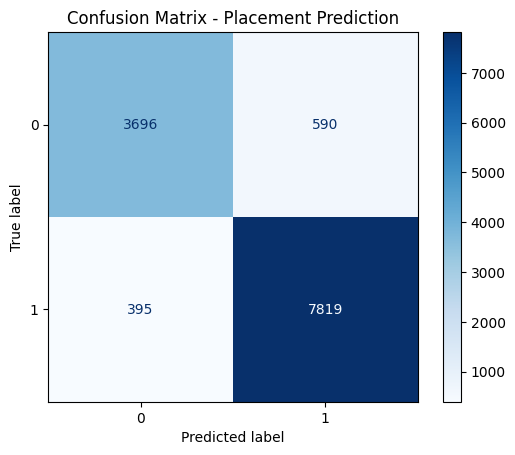


ROC CURVE


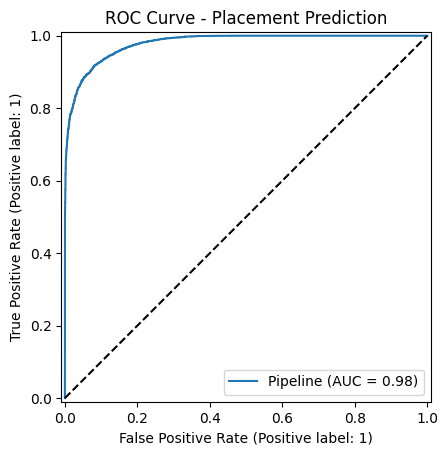


ODDS RATIOS

Odds Ratio > 1  -> higher placement odds
Odds Ratio < 1  -> lower placement odds


cat__HistoryOfBacklogs_No          3.991
num__SoftSkillsRating              3.029
num__Internships                   2.838
num__SGPA_Sem5                     2.411
num__Projects                      2.289
num__SGPA_Sem7                     2.210
num__SGPA_Sem8                     2.047
num__SGPA_Sem6                     1.941
cat__CGPA_Tier_High                1.894
num__SGPA_Sem1                     1.727
num__MockInterviewScore            1.693
num__SGPA_Sem2                     1.688
num__AptitudeTestScore             1.634
num__SGPA_Sem4                     1.600
num__SGPA_Sem3                     1.551
cat__Stream_CS                     1.546
cat__CollegeTier_Tier1             1.513
num__CodingTestScore               1.502
cat__Gender_Female                 1.333
cat__Hostel_No                     1.329
cat__Hostel_Yes                    1.315
cat__Gender_Male                   1.312
c

,Feature,Coefficient,Odds_Ratio
8,num__CGPA,-2.2430,0.1061
47,cat__HistoryOfBacklogs_No,1.3841,3.9911
16,num__SoftSkillsRating,1.1084,3.0294
10,num__Internships,1.0433,2.8385
4,num__SGPA_Sem5,0.8798,2.4105
11,num__Projects,0.8282,2.2892
48,cat__HistoryOfBacklogs_Yes,-0.8254,0.4381
6,num__SGPA_Sem7,0.7929,2.2098
7,num__SGPA_Sem8,0.7165,2.0473
5,num__SGPA_Sem6,0.6630,1.9406



FINAL MODEL SUMMARY
Dataset size          : (50000, 32)
Training samples      : 37500
Testing samples       : 12500
5-Fold CV Accuracy    : 0.9242
ROC-AUC               : 0.9794

Logistic Regression Pipeline completed successfully!


In [ ]:
# ============================================================
# FULL LOGISTIC REGRESSION PIPELINE
# PLACEMENT PREDICTION
# ============================================================

# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay
)


# ============================================================
# 2. UPLOAD DATASET
# ============================================================

print("Please upload your placement CSV file...")

uploaded = files.upload()

# Automatically get uploaded filename
filename = list(uploaded.keys())[0]

print("\nFile uploaded successfully:")
print(filename)


# ============================================================
# 3. LOAD DATASET
# ============================================================

df = pd.read_csv(filename)

print("\n============================================================")
print("DATASET INFORMATION")
print("============================================================")

print("Dataset Shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nColumn Names:")
print(df.columns.tolist())


# ============================================================
# 4. CHECK MISSING VALUES
# ============================================================

print("\n============================================================")
print("MISSING VALUES")
print("============================================================")

print(df.isnull().sum())


# ============================================================
# 5. DEFINE FEATURES
# ============================================================

# Numerical columns

NUM = [
    "SGPA_Sem1",
    "SGPA_Sem2",
    "SGPA_Sem3",
    "SGPA_Sem4",
    "SGPA_Sem5",
    "SGPA_Sem6",
    "SGPA_Sem7",
    "SGPA_Sem8",
    "CGPA",
    "AttendancePercent",
    "Internships",
    "Projects",
    "Workshops",
    "Certifications",
    "Publications",
    "AptitudeTestScore",
    "SoftSkillsRating",
    "CodingTestScore",
    "MockInterviewScore",
    "ExtraCurricular"
]


# Categorical columns

CAT = [
    "Gender",
    "City",
    "CollegeTier",
    "Stream",
    "Specialisation",
    "Hostel",
    "HistoryOfBacklogs",
    "CGPA_Tier"
]


# Target column

TARGET = "PlacementStatus"


# ============================================================
# 6. CHECK THAT REQUIRED COLUMNS EXIST
# ============================================================

required_columns = NUM + CAT + [TARGET]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:

    print("\nERROR: These columns are missing from your dataset:")
    print(missing_columns)

else:

    print("\nAll required columns are present!")


# ============================================================
# 7. CREATE X AND y
# ============================================================

X = df[NUM + CAT]

y = df[TARGET]


print("\n============================================================")
print("TARGET DISTRIBUTION")
print("============================================================")

print(y.value_counts())

print("\nTarget percentage:")

print(
    (y.value_counts(normalize=True) * 100).round(2)
)


# ============================================================
# 8. TRAIN-TEST SPLIT
# ============================================================

Xtr, Xte, ytr, yte = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("\n============================================================")
print("TRAIN-TEST SPLIT")
print("============================================================")

print("Training samples:", Xtr.shape[0])
print("Testing samples :", Xte.shape[0])


# ============================================================
# 9. NUMERICAL PREPROCESSING
# ============================================================

num_pipeline = Pipeline([

    # Fill missing numerical values with median
    ("imputer", SimpleImputer(strategy="median")),

    # Standardize numerical features
    ("scaler", StandardScaler())
])


# ============================================================
# 10. CATEGORICAL PREPROCESSING
# ============================================================

cat_pipeline = Pipeline([

    # Fill missing categorical values
    ("imputer", SimpleImputer(strategy="most_frequent")),

    # Convert categories into numerical values
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])


# ============================================================
# 11. COMBINE PREPROCESSING
# ============================================================

prep = ColumnTransformer([

    ("num", num_pipeline, NUM),

    ("cat", cat_pipeline, CAT)
])


# ============================================================
# 12. CREATE LOGISTIC REGRESSION PIPELINE
# ============================================================

clf = Pipeline([

    # Step 1: preprocessing
    ("prep", prep),

    # Step 2: logistic regression
    ("lr", LogisticRegression(max_iter=1000))
])


# ============================================================
# 13. TRAIN MODEL
# ============================================================

print("\n============================================================")
print("TRAINING LOGISTIC REGRESSION MODEL")
print("============================================================")

clf.fit(Xtr, ytr)

print("Model training completed successfully!")


# ============================================================
# 14. MAKE PREDICTIONS
# ============================================================

# Probability of placement

proba = clf.predict_proba(Xte)[:, 1]


# Predicted class

pred = clf.predict(Xte)


# ============================================================
# 15. CLASSIFICATION REPORT
# ============================================================

print("\n============================================================")
print("CLASSIFICATION REPORT")
print("============================================================")

print(
    classification_report(
        yte,
        pred,
        target_names=["Not placed", "Placed"]
    )
)


# ============================================================
# 16. ROC-AUC
# ============================================================

auc = roc_auc_score(yte, proba)

print("\n============================================================")
print("ROC-AUC")
print("============================================================")

print("ROC-AUC:", round(auc, 4))


# ============================================================
# 17. 5-FOLD CROSS VALIDATION
# ============================================================

print("\n============================================================")
print("5-FOLD CROSS VALIDATION")
print("============================================================")

cv_scores = cross_val_score(
    clf,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Fold 1 Accuracy:", round(cv_scores[0], 4))
print("Fold 2 Accuracy:", round(cv_scores[1], 4))
print("Fold 3 Accuracy:", round(cv_scores[2], 4))
print("Fold 4 Accuracy:", round(cv_scores[3], 4))
print("Fold 5 Accuracy:", round(cv_scores[4], 4))

print(
    "\nMean 5-Fold CV Accuracy:",
    round(cv_scores.mean(), 4)
)


# ============================================================
# 18. CONFUSION MATRIX
# ============================================================

print("\n============================================================")
print("CONFUSION MATRIX")
print("============================================================")

ConfusionMatrixDisplay.from_estimator(
    clf,
    Xte,
    yte,
    cmap="Blues"
)

plt.title("Confusion Matrix - Placement Prediction")

plt.show()


# ============================================================
# 19. ROC CURVE
# ============================================================

print("\n============================================================")
print("ROC CURVE")
print("============================================================")

RocCurveDisplay.from_estimator(
    clf,
    Xte,
    yte
)

plt.plot(
    [0, 1],
    [0, 1],
    "k--"
)

plt.title("ROC Curve - Placement Prediction")

plt.show()


# ============================================================
# 20. GET TRANSFORMED FEATURE NAMES
# ============================================================

feature_names = (
    clf
    .named_steps["prep"]
    .get_feature_names_out()
)


# ============================================================
# 21. GET LOGISTIC REGRESSION COEFFICIENTS
# ============================================================

coefficients = (
    clf
    .named_steps["lr"]
    .coef_[0]
)


# ============================================================
# 22. CALCULATE ODDS RATIOS
# ============================================================

odds_ratios = pd.Series(
    np.exp(coefficients),
    index=feature_names
)


# Sort from highest to lowest

odds_ratios = odds_ratios.sort_values(
    ascending=False
)


# ============================================================
# 23. DISPLAY ODDS RATIOS
# ============================================================

print("\n============================================================")
print("ODDS RATIOS")
print("============================================================")

print(
    "\nOdds Ratio > 1  -> higher placement odds"
)

print(
    "Odds Ratio < 1  -> lower placement odds"
)

print(
    "\n"
)

print(
    odds_ratios.round(3)
)


# ============================================================
# 24. TOP 15 FEATURES
# ============================================================

print("\n============================================================")
print("TOP 15 FEATURES BY ODDS RATIO")
print("============================================================")

top_features = odds_ratios.head(15)

print(
    top_features.round(3)
)


# ============================================================
# 25. LOWEST 15 FEATURES
# ============================================================

print("\n============================================================")
print("LOWEST 15 FEATURES BY ODDS RATIO")
print("============================================================")

lowest_features = (
    odds_ratios
    .tail(15)
    .sort_values(ascending=True)
)

print(
    lowest_features.round(3)
)


# ============================================================
# 26. CREATE COEFFICIENT TABLE
# ============================================================

coefficient_table = pd.DataFrame({

    "Feature": feature_names,

    "Coefficient": coefficients,

    "Odds_Ratio": np.exp(coefficients)

})


# Sort by absolute coefficient

coefficient_table["Abs_Coefficient"] = (
    coefficient_table["Coefficient"]
    .abs()
)

coefficient_table = coefficient_table.sort_values(
    "Abs_Coefficient",
    ascending=False
)


# ============================================================
# 27. DISPLAY COEFFICIENT TABLE
# ============================================================

print("\n============================================================")
print("LOGISTIC REGRESSION COEFFICIENT TABLE")
print("============================================================")

display(
    coefficient_table[
        [
            "Feature",
            "Coefficient",
            "Odds_Ratio"
        ]
    ].round(4)
)


# ============================================================
# 28. FINAL SUMMARY
# ============================================================

print("\n============================================================")
print("FINAL MODEL SUMMARY")
print("============================================================")

print("Dataset size          :", df.shape)

print("Training samples      :", len(Xtr))

print("Testing samples       :", len(Xte))

print(
    "5-Fold CV Accuracy    :",
    round(cv_scores.mean(), 4)
)

print(
    "ROC-AUC               :",
    round(auc, 4)
)

print("\nLogistic Regression Pipeline completed successfully!")